# R2 - EMBED TESTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import jscatter
from sklearn.decomposition import PCA
from umap import UMAP
import seaborn as sns

#enable pandas tdqm
from tqdm import tqdm
tqdm.pandas()


In [2]:
%cd f:/robusto/vqa_analysis

f:\robusto\vqa_analysis


# LOADING DATA

In [3]:
#load from pickle
import pickle
def load_embeddings_cache(path):
    with open(path, "rb") as f:
        embeddings_cache = pickle.load(f)
    return embeddings_cache

#first reduce all embedding cache using pca to 2 dimensions and store then into a df with agent video question answer and embedding
def build_embeding_matrix_first(df_answers, embeddings_cache):
    embeddings = []
    for idx,row in df_answers.iterrows():
        key = (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION"])
        if key in embeddings_cache:
            embedding = embeddings_cache[key]
            embeddings.append(embedding)
            
        else:
            raise ValueError(f"Embedding for key {key} not found in cache")

    embeddings_arr = np.vstack(embeddings)
    return embeddings_arr

def build_embeding_matrix_mean(df_answers, embeddings_cache):
    #group by agent video question and take the mean of the embeddings for each group
    grouped = df_answers.groupby(["AGENT", "VIDEO", "QUESTION_NUM"])
    mean_embeddings = []
    for name, group in tqdm(grouped):
        embeddings = []
        for idx,row in group.iterrows():
            key = (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION"])
            if key in embeddings_cache:
                embedding = embeddings_cache[key]
                embeddings.append(embedding)
            else:
                raise ValueError(f"Embedding for key {key} not found in cache")
        mean_embedding = np.mean(embeddings, axis=0)
        mean_embeddings.append(mean_embedding)
    mean_embeddings_arr = np.vstack(mean_embeddings)
    return mean_embeddings_arr

In [4]:
#load answers text cache
answers_text_cache_path = "./data/r2_cleaned.csv"
df_answers = pd.read_csv(answers_text_cache_path, keep_default_na=False) #keep_default_na=False to avoid converting empty strings to NaN
df_answers["VIDEO_SECTOR"] = df_answers["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
df_answers_first = df_answers.copy()[df_answers["REPETITION"] == 1].reset_index(drop=True)
print(f"Loaded answers text with {len(df_answers)} entries")
df_answers.head()

Loaded answers text with 86800 entries


,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC


# RSA ANALYSIS

In [ ]:
from scipy.stats import pearsonr,spearmanr
CHANGE_BLOCK = True

#PART 1 : rsa computation
def compute_rsa_matrices(df_answers, embeddings_arr, corr_func = spearmanr):
    agents = df_answers["AGENT"].unique()
    vlms = [agent for agent in agents if "human" not in agent]
    humans = [agent for agent in agents if "human" in agent]

    agents = humans + vlms 

    gramians = {}
    rsa_df = []
    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            print(f"Processing region {region} block {block}")
            #product the gramian matrix of all t embeds of block 
            for agent in agents:
                mask = (df_answers["AGENT"] == agent) & (df_answers["VIDEO_SECTOR"] == region) & (df_answers["BLOCK"] == block)
                df_selected = df_answers[mask] #.sort_values(by=["VIDEO", "QUESTION_NUM", "REPETITION"])
                selected_embeddings = embeddings_arr[df_selected.index]
                
                #compute the gramian matrix
                if block != 2 or CHANGE_BLOCK:
                    selected_embeddings = selected_embeddings / np.linalg.norm(selected_embeddings, axis=1, keepdims=True)
                    gramian_matrix = selected_embeddings @ selected_embeddings.T
                    gramians[(agent,block,region)] = gramian_matrix
                else:
                    r_col = df_selected["ANSWER"].astype(int).to_numpy()
                    gramians[(agent,block,region)] = r_col

            #RSA    
            #rsa_matrix = np.zeros((len(agents), len(agents)))
            for i, agent_i in enumerate(agents):
                for j, agent_j in enumerate(agents):
                    if i <= j:
                        #compute the correlation between the two gramian matrices
                        gramian_i = gramians[(agent_i,block,region)]
                        gramian_j = gramians[(agent_j,block,region)]

                        if block != 2 or CHANGE_BLOCK:
                            triu_indices = np.triu_indices_from(gramian_i, k=1)
                            gj_upper = gramian_j[triu_indices]
                            gi_upper = gramian_i[triu_indices]
                        else:
                            gj_upper = gramian_j
                            gi_upper = gramian_i
                            
                        correlation,_ = corr_func(gi_upper, gj_upper)
                        #rsa_matrix[i, j] = correlation
                        #rsa_matrix[j, i] = correlation
                       
                        
                        rsa_df.append({
                            "VIDEO_SECTOR": region,
                            "BLOCK": block,
                            "AGENT_I": agent_j,
                            "AGENT_J": agent_i,
                            "CORRELATION": correlation
                        })
                        if agent_i != agent_j:
                            rsa_df.append({
                                "VIDEO_SECTOR": region,
                                "BLOCK": block,
                                "AGENT_I": agent_i,
                                "AGENT_J": agent_j,
                                "CORRELATION": correlation
                            })
    
    rsa_df = pd.DataFrame(rsa_df)
    return rsa_df, gramians, agents

def plot_rsa_matrices(rsa_df, agents, title):
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),sharex=True,sharey=True)

    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()[::-1]):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            
            #select the data for the region and block
            df_block = rsa_df[(rsa_df["VIDEO_SECTOR"] == region) & (rsa_df["BLOCK"] == block)]
            rsa_matrix = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="CORRELATION")
            
            #order columns and rows by agents order
            rsa_matrix = rsa_matrix.reindex(index=agents, columns=agents)
            sns.heatmap(rsa_matrix.to_numpy(), annot=False, xticklabels=rsa_matrix.columns, yticklabels=rsa_matrix.columns, cmap=c, ax=c_ax,square=True, vmin=-1, vmax=1,annot_kws={"fontsize":7})
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
            
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    #print(f"Saving RSA plot with title: {title} as rsa_output_{out_name}.png")
    fig.tight_layout()
    #fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)
    return fig
    
def check_gramians(gramians, agent, region):
    fig,ax = plt.subplots(1,5, figsize=(20,4))
    fig.suptitle(f"Matrices of Gramian {agent} | {region}", fontsize=24, weight="bold")
    ax = ax.flatten()
    
    for i in range(1,4):
        gemini = gramians[(agent,i,region)]
        sns.heatmap(gemini * gemini.T,cmap="viridis", vmin=-1, vmax=1,ax=ax[i-1],square=True)
        ax[i-1].set_title(f"Block {i}", fontsize=16)
    fig.tight_layout()
    
    
#PART 2: stats of rsa matrices (mean and std of correlation between groups)
def categorize_agent(agente):
    agente = agente.lower()
    if "lima" in agente:
        return "Human_lima"
    elif "nyc" in agente or "new york" in agente:
        return "Human_nyc"
    else:
        return "Vlm"

def get_stat_dict(df):
    df = df.copy()
    r = {}
    df['GROUP_I'] = df['AGENT_I'].apply(categorize_agent)
    df['GROUP_J'] = df['AGENT_J'].apply(categorize_agent)
    
    for sector in df['VIDEO_SECTOR'].unique():
        for bloque in df['BLOCK'].unique():
            print(f"Processing sector {sector} block {bloque}")
            df_filtered = df[(df['VIDEO_SECTOR'] == sector) & (df['BLOCK'] == bloque)].copy()
            mean_mtx = df_filtered.pivot_table(
                index='GROUP_I', columns='GROUP_J', values='CORRELATION', aggfunc='mean'
            )
            std_mtx = df_filtered.pivot_table(
                index='GROUP_I', columns='GROUP_J', values='CORRELATION', aggfunc='std'
            )
            r[(sector, bloque)] = (mean_mtx, std_mtx)
    
    return r

def plot_individual_stat_matrices(ax, mean_mtx, std_mtx):
    annot_text = []
    for i in range(len(mean_mtx)):
        row = []
        for j in range(len(mean_mtx.columns)):
            m = mean_mtx.iloc[i, j]
            s = std_mtx.iloc[i, j]
            row.append(f"{m:.2f}±{s:.2f}")
        annot_text.append(row)

    # 2. Graficar usando la media para el color
    sns.heatmap(
        mean_mtx.to_numpy(), 
        annot=annot_text, # Aquí pasamos nuestro texto formateado
        fmt="",           # Necesario para que acepte strings
        cmap='RdBu_r',    # Rojo para pos, Azul para neg (típico en RSA)
        center=0, 
        vmin=-1, 
        vmax=1,
        annot_kws={"fontsize": 12, "weight": "bold"},
        square=True,
        xticklabels=mean_mtx.columns,
        yticklabels=mean_mtx.columns,
        ax=ax
    )
    
def plot_rsa_stats(r_dict,agents,title):
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),sharex=True,sharey=True)
    
    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()[::-1]):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            mean_mtx, std_mtx = r_dict[(region, block)]
            plot_individual_stat_matrices(c_ax, mean_mtx, std_mtx)
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
    
    out_name = title.replace(" ", "_").replace(":","-").lower()
    fig.suptitle(title, fontsize=24, weight="bold")
    fig.tight_layout()
    #fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)
    return fig

In [23]:
def make_rsa_analysis(df_answers, cache_path, corr_func = pearsonr):
    emdeds_cache = load_embeddings_cache(cache_path)
    embeds_matrix = build_embeding_matrix_first(df_answers, emdeds_cache)
    rsas,gramians,agents = compute_rsa_matrices(df_answers, embeds_matrix, corr_func=corr_func)
    
    stats = get_stat_dict(rsas)
    #hacky way to get the name 
    #get the file name without extension
    file_name = os.path.basename(cache_path)
    args = file_name.split("_")
    embed = args[0]
    batch = args[1]
    dataset = args[2]
    print("Plotting RSA matrices...")
    figA = plot_rsa_matrices(rsas, agents, f"RSA analysis - Embed {embed} - {batch} - Func {corr_func.__name__} - Dataset {dataset}")
    figB = plot_rsa_stats(stats,agents, f"RSA stats by group (Mean and std) - Embed {embed} - {batch} - Func {corr_func.__name__} - Dataset {dataset}")
    return rsas, gramians, agents,figA, figB

## RSA Allmpnet - Batch 1 - Pearsonr

Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
Processing region NYC block 4
Processing region LIMA block 1
Processing region LIMA block 2
Processing region LIMA block 3
Processing region LIMA block 4
Processing sector NYC block 1
Processing sector NYC block 2
Processing sector NYC block 3
Processing sector NYC block 4
Processing sector LIMA block 1
Processing sector LIMA block 2
Processing sector LIMA block 3
Processing sector LIMA block 4
Plotting RSA matrices...


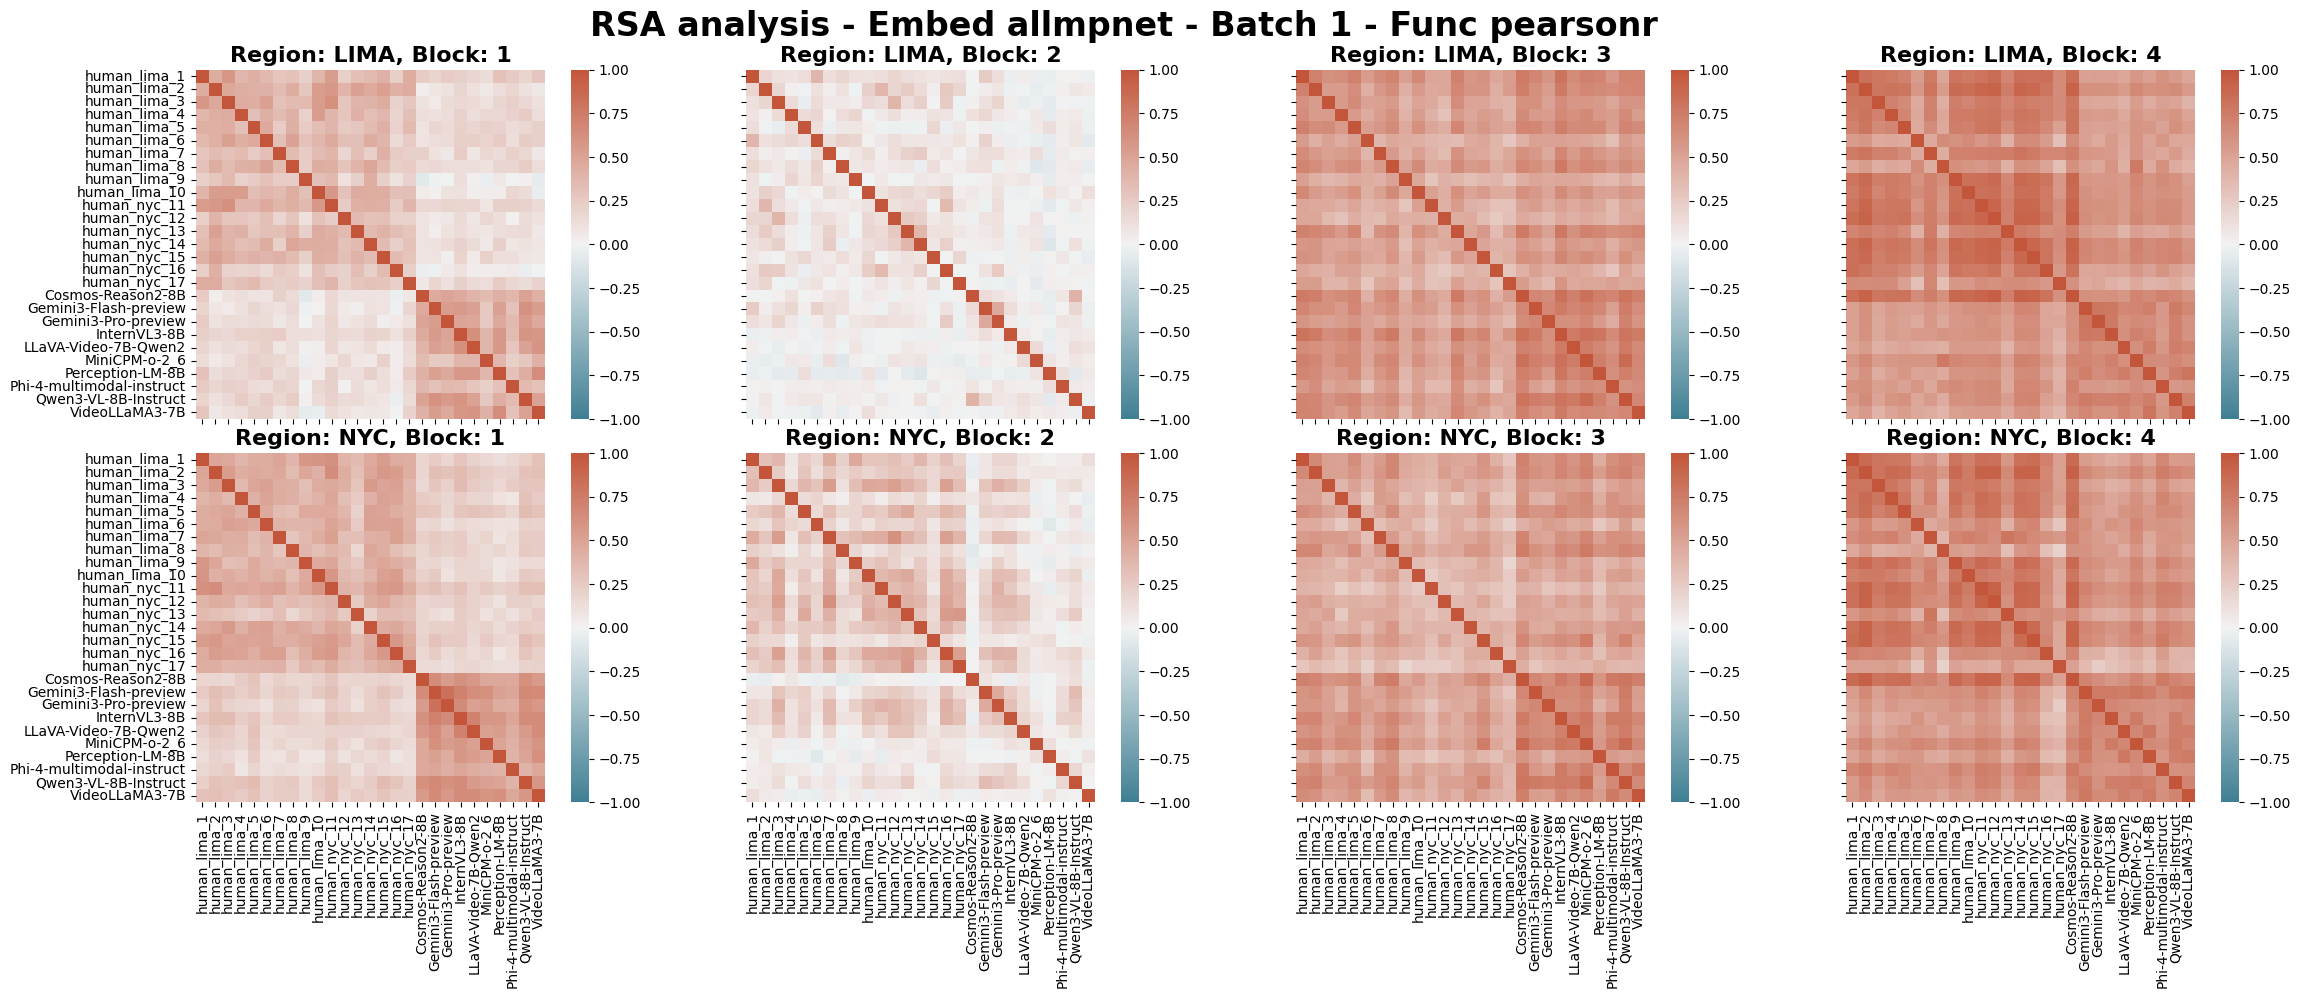

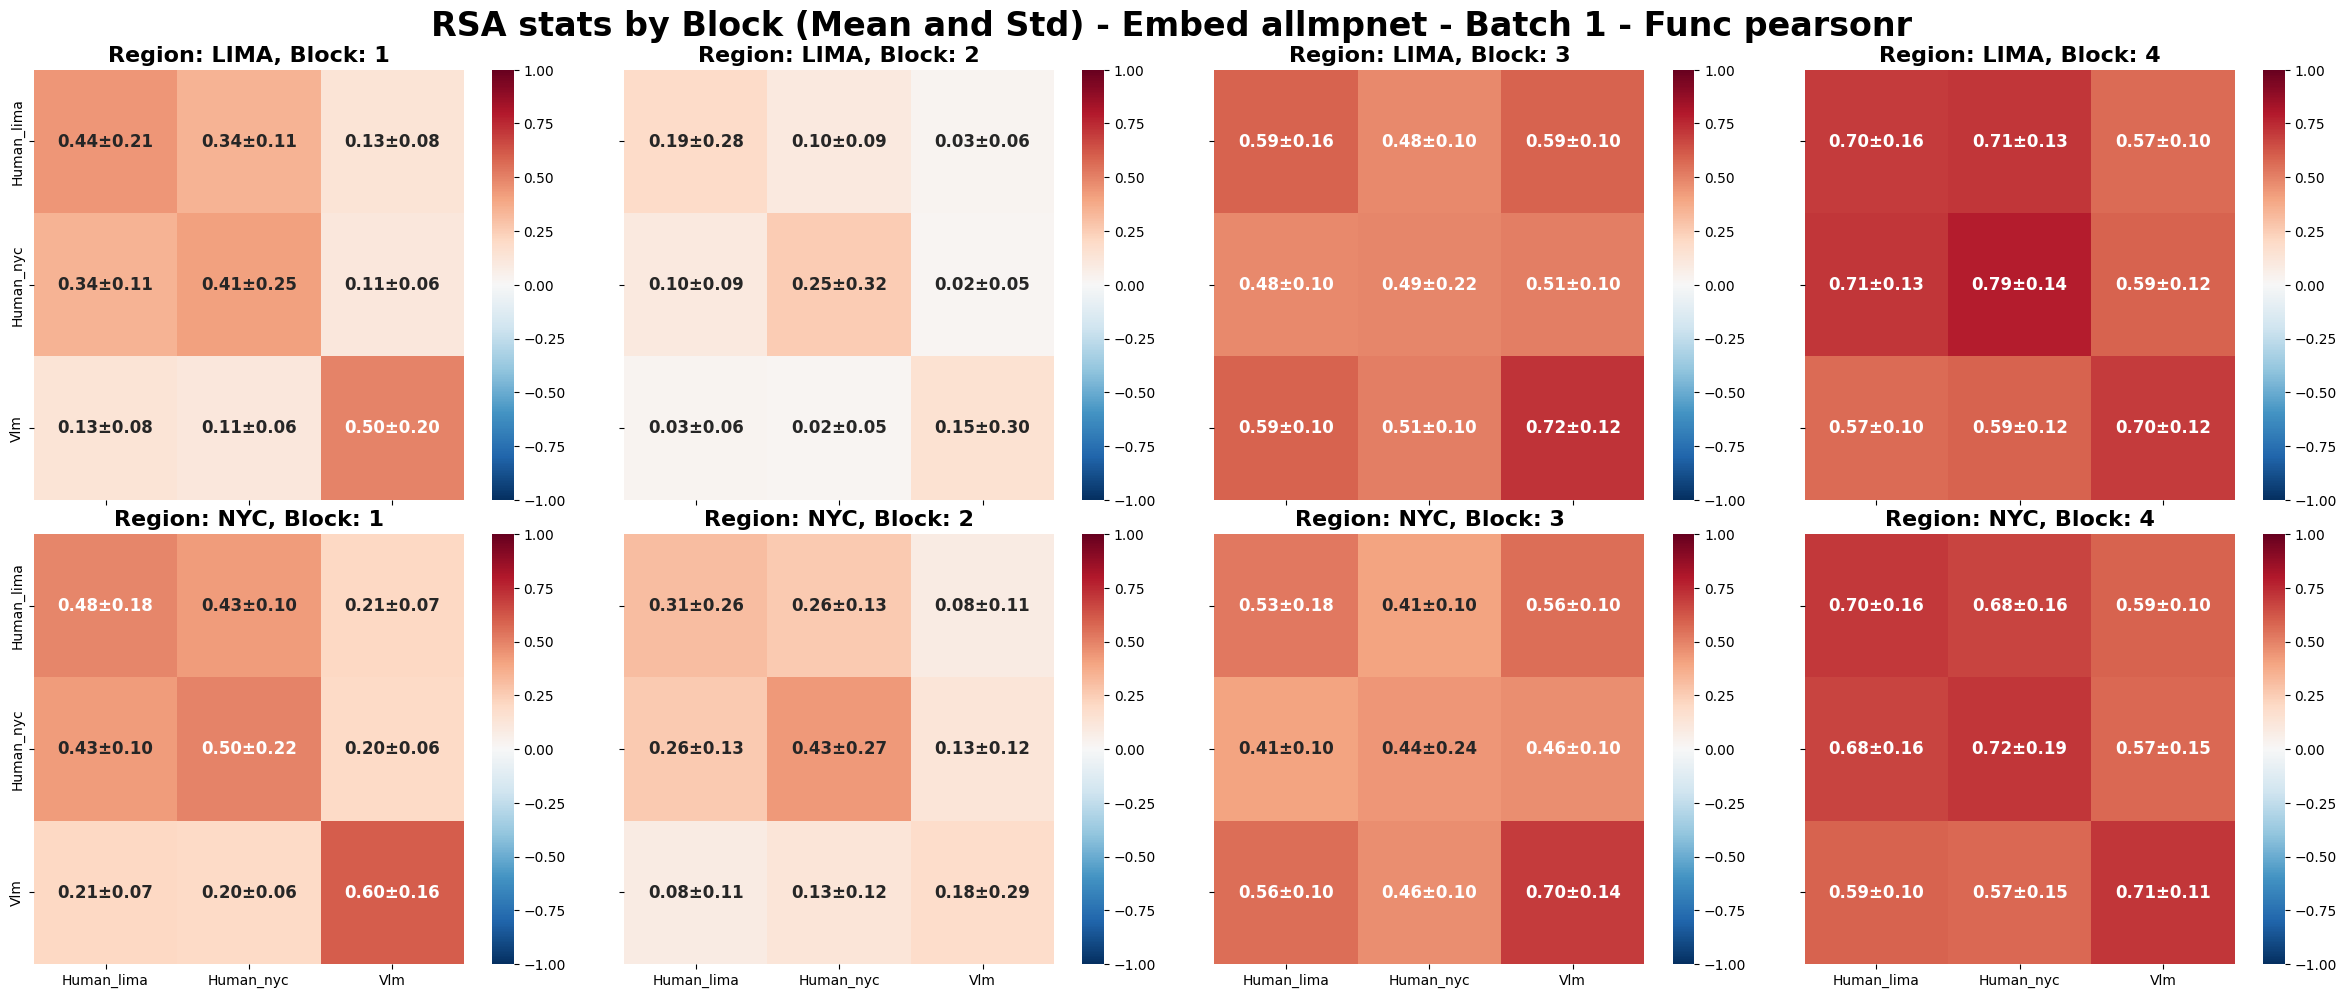

In [26]:
path = "./outputs/output_embeddings_cleaned_allmpnet/embeddings_cache_keyed_allmpnet.pkl"
rsas,_,_,figA,figB = make_rsa_analysis(df_answers_first,path, corr_func=pearsonr)
figA.suptitle(f"RSA analysis - Embed allmpnet - Batch 1 - Func pearsonr", fontsize=24, weight="bold")
figA.subplots_adjust(top=0.92)
figA.savefig(f"./rsa_output_allmpnet_batch_1_func_pearsonr.png",dpi =300)

figB.suptitle(f"RSA stats by Block (Mean and Std) - Embed allmpnet - Batch 1 - Func pearsonr", fontsize=24, weight="bold")
figB.subplots_adjust(top=0.92)
figB.savefig(f"./rsa_output_stats_allmpnet_batch_1_func_pearsonr.png",dpi=300)

## RSA Qwen - Batch 1 - Pearson

In [18]:
path = "./external_embeds/qwen_batch1_r2_embeddings_cache_keyed.pkl"
rsa,_,_ = make_rsa_analysis(df_answers,path, corr_func=pearsonr)

ValueError: Embedding for key ('human_nyc_16', 'Robusto2_153', 1, 1) not found in cache

## R1 - REPRODUCTION

In [ ]:
ORDER_AGENTS = [
    'cogvlm2',     # El camaleón de visual help
    'qwen2',       # El logo geométrico de Alibaba
    'gemini-2.0',  # La G de Google
    'pixtral',     # El logo de Mistral (la H estilizada)
    'Llama-3.2',   # El logo de Meta
    'deepseek_v2'  # La ballena
]

#JOIN THE HUMANS
ORDER_AGENTS = ORDER_AGENTS + [f"Humano{i}" for i in range(1, 10)]
ORDER_AGENTS

['cogvlm2',
 'qwen2',
 'gemini-2.0',
 'pixtral',
 'Llama-3.2',
 'deepseek_v2',
 'Humano1',
 'Humano2',
 'Humano3',
 'Humano4',
 'Humano5',
 'Humano6',
 'Humano7',
 'Humano8',
 'Humano9']

In [ ]:
from scipy.stats import pearsonr,spearmanr
CHANGE_BLOCK = True
def compute_rsa_matrices(df_answers, embeddings_arr, corr_func = spearmanr):
    #agents = df_answers["AGENT"].unique()
    #vlms = [agent for agent in agents if "Humano" not in agent]
    #humans = [agent for agent in agents if "Humano" in agent]

    agents = ORDER_AGENTS #vlms + humans

    rsas = {}
    gramians = {}
    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            print(f"Processing region {region} block {block}")
            #product the gramian matrix of all t embeds of block 
            for agent in agents:
                mask = (df_answers["AGENT"] == agent) & (df_answers["VIDEO_SECTOR"] == region) & (df_answers["BLOCK"] == block)
                df_selected = df_answers[mask] #.sort_values(by=["VIDEO", "QUESTION_NUM", "REPETITION"])
                selected_embeddings = embeddings_arr[df_selected.index]
                
                #compute the gramian matrix
                selected_embeddings = selected_embeddings / np.linalg.norm(selected_embeddings, axis=1, keepdims=True)
                gramian_matrix = selected_embeddings @ selected_embeddings.T
                gramians[(agent,block,region)] = gramian_matrix
            #RSA    
            rsa_matrix = np.zeros((len(agents), len(agents)))
            for i, agent_i in enumerate(agents):
                for j, agent_j in enumerate(agents):
                    if i <= j:
                        #compute the correlation between the two gramian matrices
                        gramian_i = gramians[(agent_i,block,region)]
                        gramian_j = gramians[(agent_j,block,region)]
                        triu_indices = np.triu_indices_from(gramian_i, k=1)
                        gj_upper = gramian_j[triu_indices]
                        gi_upper = gramian_i[triu_indices]
                        correlation,_ = corr_func(gi_upper, gj_upper)
                        rsa_matrix[i, j] = correlation
                        rsa_matrix[j, i] = correlation
                        rsas[(region, block)] = rsa_matrix
    return rsas, gramians, agents
                            
def plot_rsa_matrices(df_answers,rsas, agents, title):
    nrows = len(df_answers["VIDEO_SECTOR"].unique())
    ncols = len(df_answers["BLOCK"].astype(int).unique())
    
    fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows),sharex=True,sharey=True)
    ax = ax.reshape(nrows, ncols)
    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            rsa_matrix = rsas[(region, block)]
            sns.heatmap(rsa_matrix, annot=True, xticklabels=agents, yticklabels=agents, cmap=c, ax=c_ax,square=True, vmin=-1, vmax=1,annot_kws={"fontsize":6}, fmt=".2f")
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    print(f"Saving RSA plot with title: {title} as rsa_output_{out_name}.png")
    fig.tight_layout()
    fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)

    
def remove_repetitions_by_mean_embeds(df_answers, embeddings_cache):
    #the embebedings dictionary cache has keys of the form (agent, video, question_num, repetition) and values of the form embedding vector
    #we want to remove the repetition dimension by averaging the embeddings of the same agent, video and question_num
    mean_embedding_cache = {}
    #group by agent video question_num and average the embeddings
    #remore the rows where the answer where is empty string or [Empty]
    print(f"Input shape of answers df: {df_answers.shape}")
    df_answers = df_answers.copy()[~df_answers["ANSWER"].isin(["", "[Empty]"])].reset_index(drop=True)
    print(f"Removed empty answers, new shape of answers df: {df_answers.shape}")

    grouped = df_answers.groupby(["AGENT", "VIDEO", "QUESTION_NUM"])
    #iterate over the groups and average the embeddings
    for agent, video, question_num in grouped.groups.keys():
        group_indices = grouped.groups[(agent, video, question_num)]
        embeddings = []
        for repetition in df_answers.loc[group_indices, "REPETITION"]:
            #Check if answer value if not [Empty]
            key = (agent, video, question_num, repetition)
            if key in embeddings_cache:
                embeddings.append(embeddings_cache[key])
            else:
                raise ValueError(f"Embedding for key {key} not found in cache")
        mean_embedding = np.mean(embeddings, axis=0)
        mean_embedding_cache[(agent, video, question_num)] = mean_embedding
        
    #now remove the reptitions from the df_answers
    mean_answers_df = grouped.first().reset_index()
    print(f"Removed repetitions, new shape of answers df: {mean_answers_df.shape}")
    return mean_answers_df, mean_embedding_cache

def build_embeding_matrix(df_answers, embeddings_cache):
    embeddings = []
    for idx,row in df_answers.iterrows():
        key = (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"])
        if key in embeddings_cache:
            embedding = embeddings_cache[key]
            embeddings.append(embedding)
        else:
            raise ValueError(f"Embedding for key {key} not found in cache")

    embeddings_arr = np.vstack(embeddings)
    return embeddings_arr
    
def make_rsa_analysis(df_answers, cache_path, corr_func = pearsonr):
    emdeds_cache = load_embeddings_cache(cache_path)
    df_answers_no_reps, mean_embedding_cache = remove_repetitions_by_mean_embeds(df_answers, emdeds_cache)
    embeds_matrix = build_embeding_matrix(df_answers_no_reps,mean_embedding_cache)
    rsas,gramians,agents = compute_rsa_matrices(df_answers_no_reps, embeds_matrix, corr_func=corr_func)
    print(rsas.keys())
    #hacky way to get the name 
    #get the file name without extension
    file_name = os.path.basename(cache_path)
    args = file_name.split("_")
    embed = args[0]
    batch = args[1]
    dataset = args[2]
    print("Plotting RSA matrices...")
    plot_rsa_matrices(df_answers, rsas, agents, f"RSA analysis - Embed {embed} - {batch} - Func {corr_func.__name__} - Dataset {dataset}")

Input shape of answers df: (6405, 8)
Removed empty answers, new shape of answers df: (6294, 8)
Removed repetitions, new shape of answers df: (1575, 8)
Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
dict_keys([('NYC', np.int64(1)), ('NYC', np.int64(2)), ('NYC', np.int64(3))])
Plotting RSA matrices...
Saving RSA plot with title: RSA analysis - Embed allmpnet - batch1 - Func pearsonr - Dataset r1 as rsa_output_rsa_analysis_-_embed_allmpnet_-_batch1_-_func_pearsonr_-_dataset_r1.png


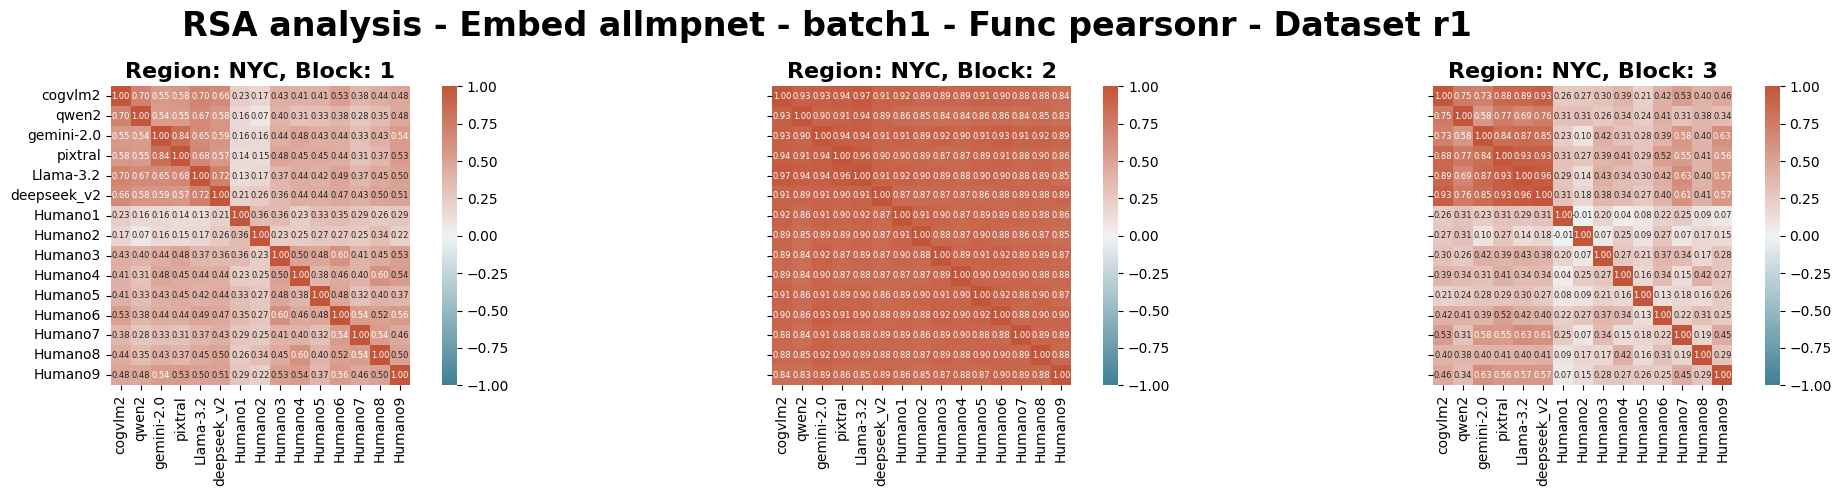

In [ ]:
df_r1 = pd.read_csv("./data/r1_cleaned.csv", keep_default_na=False)
df_r1["VIDEO_SECTOR"] = df_r1["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
make_rsa_analysis(df_r1,"./external_embeds/allmpnet_batch1_r1_embeddings_cache_keyed.pkl", corr_func=pearsonr)

Input shape of answers df: (6405, 8)
Removed empty answers, new shape of answers df: (6294, 8)
Removed repetitions, new shape of answers df: (1575, 8)
Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
dict_keys([('NYC', np.int64(1)), ('NYC', np.int64(2)), ('NYC', np.int64(3))])
Plotting RSA matrices...
Saving RSA plot with title: RSA analysis - Embed allmpnet - batch64 - Func pearsonr - Dataset r1 as rsa_output_rsa_analysis_-_embed_allmpnet_-_batch64_-_func_pearsonr_-_dataset_r1.png


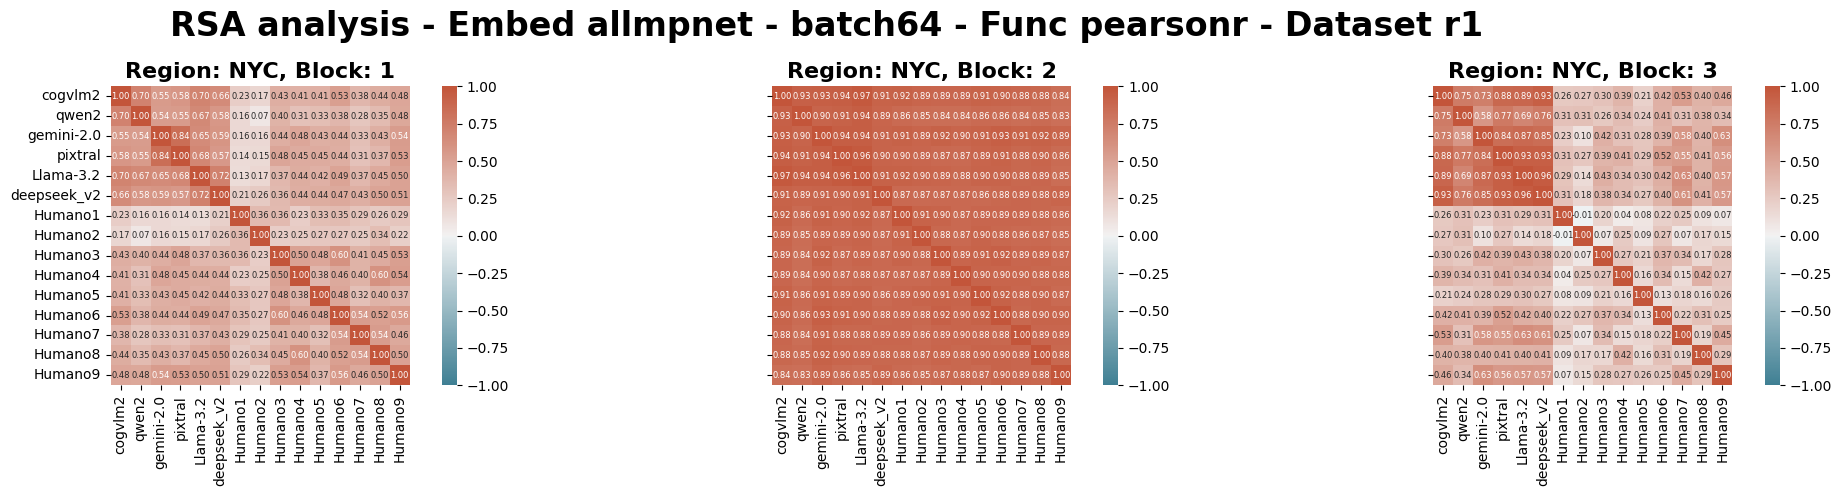

In [ ]:
df_r1 = pd.read_csv("./data/r1_cleaned.csv", keep_default_na=False)
df_r1["VIDEO_SECTOR"] = df_r1["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
make_rsa_analysis(df_r1,"./external_embeds/allmpnet_batch64_r1_embeddings_cache_keyed.pkl", corr_func=pearsonr)

# EMBED ANALYSIS

In [9]:
coords_PCA = np.zeros((len(df_answers_first), 2))
coords_UMAP = np.zeros((len(df_answers_first), 2))

path = "./outputs/output_embeddings_cleaned_allmpnet/embeddings_cache_keyed_allmpnet.pkl"
embd_test = load_embeddings_cache(path)
embeddings_arr = build_embeding_matrix_first(df_answers_first, embd_test)
print("Starting dimensionality reduction by blocks...")
for block in [1, 2, 3, 4]:
    mask = df_answers_first["BLOCK"] == block
    print(f"Processing block {block} with {mask.sum()} entries")
    if mask.any():
        pca_block = PCA(n_components=2)
        #umap_block = UMAP(n_components=2, random_state=42)
        coords_PCA[mask.values] = pca_block.fit_transform(embeddings_arr[mask.values])
        #coords_UMAP[mask.values] = umap_block.fit_transform(embeddings_arr[mask.values])

Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries


In [10]:
import src.old.config
df_plot = df_answers_first.assign(pca_X=coords_PCA[:, 0], pca_Y=coords_PCA[:, 1])
df_plot = df_plot.assign(umap_X=coords_UMAP[:, 0], umap_Y=coords_UMAP[:, 1])
def get_group_color(agent):
    if "human" in agent:
        if "nyc" in agent:
            return "nyc"
        else:
            return "lima"
    else:
        return "vlm"
    
color_map = {
    "nyc": src.old.config.PLOT_COLORS["HUMAN_LIMA"], # Cian neón (sustituye al azul oscuro que no se ve)
    "lima": src.old.config.PLOT_COLORS["HUMAN_LIMA"], # Naranja-Rojo vibrante
    "vlm": src.old.config.PLOT_COLORS["VLM"], # Verde eléctrico (el que ya tienes, funciona bien)
}

df_plot["group"] = df_plot["AGENT"].map(get_group_color)
df_plot.group

Workspace root set to: f:\robusto\vqa_analysis


0        lima
1        lima
2        lima
3        lima
4        lima
         ... 
10795     vlm
10796     vlm
10797     vlm
10798     vlm
10799     vlm
Name: group, Length: 10800, dtype: str

In [11]:
import pandas as pd
import numpy as np

BLOCK_TO_PLOT = int(input("Enter the block number to plot (1-4): "))
df_block = df_plot[df_plot["BLOCK"] == BLOCK_TO_PLOT].copy().reset_index(drop=True)
# Sample data
# Create an interactive scatter plot
scatterA = jscatter.Scatter(
    data= df_block,  # Filter for block 1
    x='pca_X',
    y='pca_Y',
    color_by='group',
    color_map=color_map,
    opacity=0.9,
    background_color="#FFFFFFF",
    axes = True,
    title=f"PCA Scatter Plot for Block {BLOCK_TO_PLOT}",
    tooltip=True,
    height=600,
    tooltip_preview= "ANSWER",
    tooltip_preview_type="text",
    tooltip_properties=["pca_X","pca_Y","AGENT", "VIDEO", "QUESTION_NUM"],
    tooltip_histograms_size="large",
    tooltip_size="medium"
)
scatterA.axes(labels=['PCA 1', 'PCA 2'])

scatterB = jscatter.Scatter(
    data= df_block,  # Filter for block 1
    x='umap_X',
    y='umap_Y',
    color_by='group',
    color_map=color_map,
    opacity=0.9,
    background_color="#FFFFFFF",
    axes = True,
    title=f"PCA Scatter Plot for Block {BLOCK_TO_PLOT}",
    tooltip=True,
    tooltip_preview= "ANSWER",
    tooltip_preview_type="text",
    tooltip_properties=["umap_X","umap_Y","AGENT", "VIDEO", "QUESTION_NUM"],
    tooltip_histograms_size="large",
    tooltip_size="medium"
)
scatterB.axes(labels=['UMAP 1', 'UMAP 2'])


print(f"Displaying scatter plot  of Block {BLOCK_TO_PLOT}...")
# jscatter.link([scatterA, scatterB],row_height = 640)
scatterA.selection(df_block.query("ANSWER == '4'").index)
jscatter.link([scatterA, scatterB], row_height=640)

Displaying scatter plot  of Block 2...


GridBox(children=(VBox(children=(HBox(children=(VBox(children=(<jscatter.widgets.button.Button object at 0x000…

In [12]:
scatterA.selection(df_block.query("group == 'lima'").index)

In [13]:
indexs = scatterA.selection()
print(f"Selected indices: {len(indexs)}")
for i in indexs:
    print(df_block.iloc[i,5].encode())

Selected indices: 1000
b'4'
b'3'
b'5'
b'9'
b'7'
b'6'
b'3'
b'6'
b'8'
b'5'
b'5'
b'6'
b'7'
b'9'
b'8'
b'3'
b'5'
b'7'
b'8'
b'7'
b'5'
b'8'
b'4'
b'7'
b'7'
b'5'
b'3'
b'7'
b'6'
b'4'
b'6'
b'7'
b'9'
b'5'
b'6'
b'6'
b'8'
b'6'
b'9'
b'9'
b'8'
b'7'
b'10'
b'9'
b'8'
b'7'
b'9'
b'8'
b'10'
b'10'
b'6'
b'7'
b'7'
b'6'
b'8'
b'8'
b'7'
b'8'
b'7'
b'8'
b'10'
b'6'
b'8'
b'8'
b'10'
b'9'
b'7'
b'7'
b'10'
b'8'
b'5'
b'4'
b'2'
b'5'
b'8'
b'7'
b'6'
b'6'
b'10'
b'7'
b'5'
b'7'
b'10'
b'4'
b'6'
b'7'
b'6'
b'5'
b'7'
b'8'
b'8'
b'7'
b'10'
b'9'
b'7'
b'9'
b'8'
b'7'
b'8'
b'9'
b'4'
b'4'
b'6'
b'8'
b'8'
b'4'
b'4'
b'5'
b'6'
b'7'
b'8'
b'7'
b'9'
b'10'
b'9'
b'9'
b'5'
b'7'
b'7'
b'8'
b'4'
b'5'
b'5'
b'6'
b'7'
b'4'
b'5'
b'5'
b'7'
b'9'
b'5'
b'8'
b'10'
b'4'
b'6'
b'7'
b'5'
b'6'
b'6'
b'7'
b'8'
b'9'
b'10'
b'9'
b'8'
b'9'
b'8'
b'8'
b'7'
b'8'
b'5'
b'8'
b'8'
b'8'
b'5'
b'7'
b'6'
b'7'
b'9'
b'5'
b'7'
b'5'
b'8'
b'10'
b'7'
b'7'
b'6'
b'7'
b'10'
b'8'
b'6'
b'8'
b'4'
b'8'
b'7'
b'7'
b'6'
b'7'
b'10'
b'5'
b'5'
b'7'
b'8'
b'2'
b'8'
b'5'
b'8'
b'6'
b'4'
b'9'
b'6'
b'7'
b'

# FINAL PLOTS

In [14]:
#assign region to each point in the scatter plot based on the video sector
#rule to check video sector Robusto2_XXX => if int(XXX) <= 100 => Lima else NYC
df_plot["VIDEO_SECTOR"] = df_plot["VIDEO"].apply(lambda x: "Lima" if int(x.split("_")[1]) <= 100 else "NYC")
df_plot

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR,pca_X,pca_Y,umap_X,umap_Y,group
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC,-0.427151,-0.002839,0.0,0.0,lima
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC,-0.419987,0.003003,0.0,0.0,lima
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC,-0.407566,0.032630,0.0,0.0,lima
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC,-0.140747,0.037365,0.0,0.0,lima
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC,-0.447533,-0.065925,0.0,0.0,lima
...,...,...,...,...,...,...,...,...,...,...,...,...
10795,VideoLLaMA3-7B,Robusto2_195,4,16,1,"The yellow taxi has the right of way, as it is...",NYC,0.239285,-0.116713,0.0,0.0,vlm
10796,VideoLLaMA3-7B,Robusto2_195,4,17,1,The video does not provide information on pede...,NYC,0.314724,0.055569,0.0,0.0,vlm
10797,VideoLLaMA3-7B,Robusto2_195,4,18,1,The probability of a crash occurring in the mo...,NYC,-0.125690,-0.345912,0.0,0.0,vlm
10798,VideoLLaMA3-7B,Robusto2_195,4,19,1,There is one pedestrian present in the scene.,NYC,0.169268,0.158384,0.0,0.0,vlm


In [15]:
import src.old.config
def plot_by_block_sector(df: pd.DataFrame,color_map : dict[str, int], title : str, reverse_z_order : bool) -> None:
    """
    Crea un grid de scatter plots (matriz) donde las filas son los sectores (Lima, NYC)
    y las columnas son los bloques (1-4). Todas las subplots comparten la misma ventana de dimensiones.
    Se añade una leyenda global a la derecha y cada punto tiene su símbolo según config.AGENT_MARKERS_MAP.
    Incluye líneas de grilla en cada subplot.
    """
    
    print("\n=== PCA por Block y Sector (Grid) ===")
    sectores = ['Lima', 'NYC']
    bloques = sorted(df["BLOCK"].unique())
    n_rows = len(sectores)
    n_cols = len(bloques)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), sharex=True, sharey=True)
    if n_rows == 1 or n_cols == 1:
        axes = axes.reshape((n_rows, n_cols))
    # Calcular límites globales
    min_x = df["pca_X"].min()
    max_x = df["pca_X"].max()
    min_y = df["pca_Y"].min()
    max_y = df["pca_Y"].max()
    x_padding = (max_x - min_x) * 0.05
    y_padding = (max_y - min_y) * 0.05
    min_x -= x_padding
    max_x += x_padding
    min_y -= y_padding
    max_y += y_padding
    # Para leyenda global
    handles_dict = {}
    for i, sector in enumerate(sectores):
        for j, block in enumerate(bloques):
            ax = axes[i, j]
            block_mask = df["BLOCK"] == block
            sector_mask = df["VIDEO_SECTOR"] == sector
            df_subset = df[block_mask & sector_mask]
            if len(df_subset) < 1:
                ax.set_title(f"Block {block} - {sector}\n(Sin datos)")
                ax.axis('off')
                continue
            # Graficar cada agente con su símbolo
            for agent in df_subset["AGENT"].unique()[::-1 if reverse_z_order else 1]:  # Revertir el orden de los agentes para controlar el z-order
                agent_mask = df_subset["AGENT"] == agent
                marker = src.old.config.AGENT_MARKERS_MAP.get(agent, 'o')
                group = df_subset[agent_mask]["group"].iloc[0]
                color = color_map[group]
                sc = ax.scatter(
                    df_subset[agent_mask]["pca_X"],
                    df_subset[agent_mask]["pca_Y"],
                    label=agent,
                    marker=marker,
                    color=color,
                    alpha=0.5,
                    edgecolors='white',
                    s=30,
                    linewidth=0.5
                )
                # Guardar handle para leyenda global
                if agent not in handles_dict:
                    handles_dict[agent] = sc
            ax.set_title(f"Block {block} - {sector}", weight="bold", fontsize=14)
            ax.set_xlabel("PC 1")
            ax.set_ylabel("PC 2")
            ax.set_xlim(min_x, max_x)
            ax.set_ylim(min_y, max_y)
            ax.grid(True, alpha=0.3)  # Añadir grid lines
    fig.legend(
        handles=list(handles_dict.values()),
        labels=list(handles_dict.keys()),
        loc='center right',
        frameon=True,
        bbox_to_anchor=(1.03, 0.5),
        fontsize=12,
        title_fontproperties={'weight': 'bold','size': 14},
        title="Agent"
    )
    
    fig.suptitle(title, fontsize=24, weight="bold")
    return fig, axes

In [16]:
#test plot giving a ax with a df to plot
import src.old.config
def plot_embeds(df_answers, embeddings_arr,color_map, title, reverse_z_order = False):
    coords_PCA = np.zeros((len(df_answers), 2))
    coords_UMAP = np.zeros((len(df_answers), 2))
    print("Starting dimensionality reduction by blocks...")
    for block in [1, 2, 3, 4]:
        mask = df_answers["BLOCK"] == block
        print(f"Processing block {block} with {mask.sum()} entries")
        if mask.any():
            pca_block = PCA(n_components=2)
            #umap_block = UMAP(n_components=2, random_state=42)
            coords_PCA[mask.values] = pca_block.fit_transform(embeddings_arr[mask.values])

    interactive = df_answers.assign(pca_X=coords_PCA[:, 0], pca_Y=coords_PCA[:, 1])
    interactive = interactive.assign(umap_X=coords_UMAP[:, 0], umap_Y=coords_UMAP[:, 1])
    def get_group_color(agent):
        if "human" in agent:
            if "nyc" in agent:
                return "nyc"
            else:
                return "lima"
        else:
            return "vlm"
        
    interactive["group"] = interactive["AGENT"].map(get_group_color)
    interactive["VIDEO_SECTOR"] = interactive["VIDEO"].apply(lambda x: "Lima" if int(x.split("_")[1]) <= 100 else "NYC")
    interactive_non_empty = interactive[interactive["ANSWER"] != ""]
    fig, r = plot_by_block_sector(interactive_non_empty,color_map,title, reverse_z_order)
    return fig
    #save it to svg
    #fig.savefig("./pca_by_block_sector.svg", bbox_inches='tight')

Embeddings array shape: (10800, 768)
Plotting with color map 1...
Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries

=== PCA por Block y Sector (Grid) ===
Plotting with color map 2...
Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries

=== PCA por Block y Sector (Grid) ===


KeyboardInterrupt: 

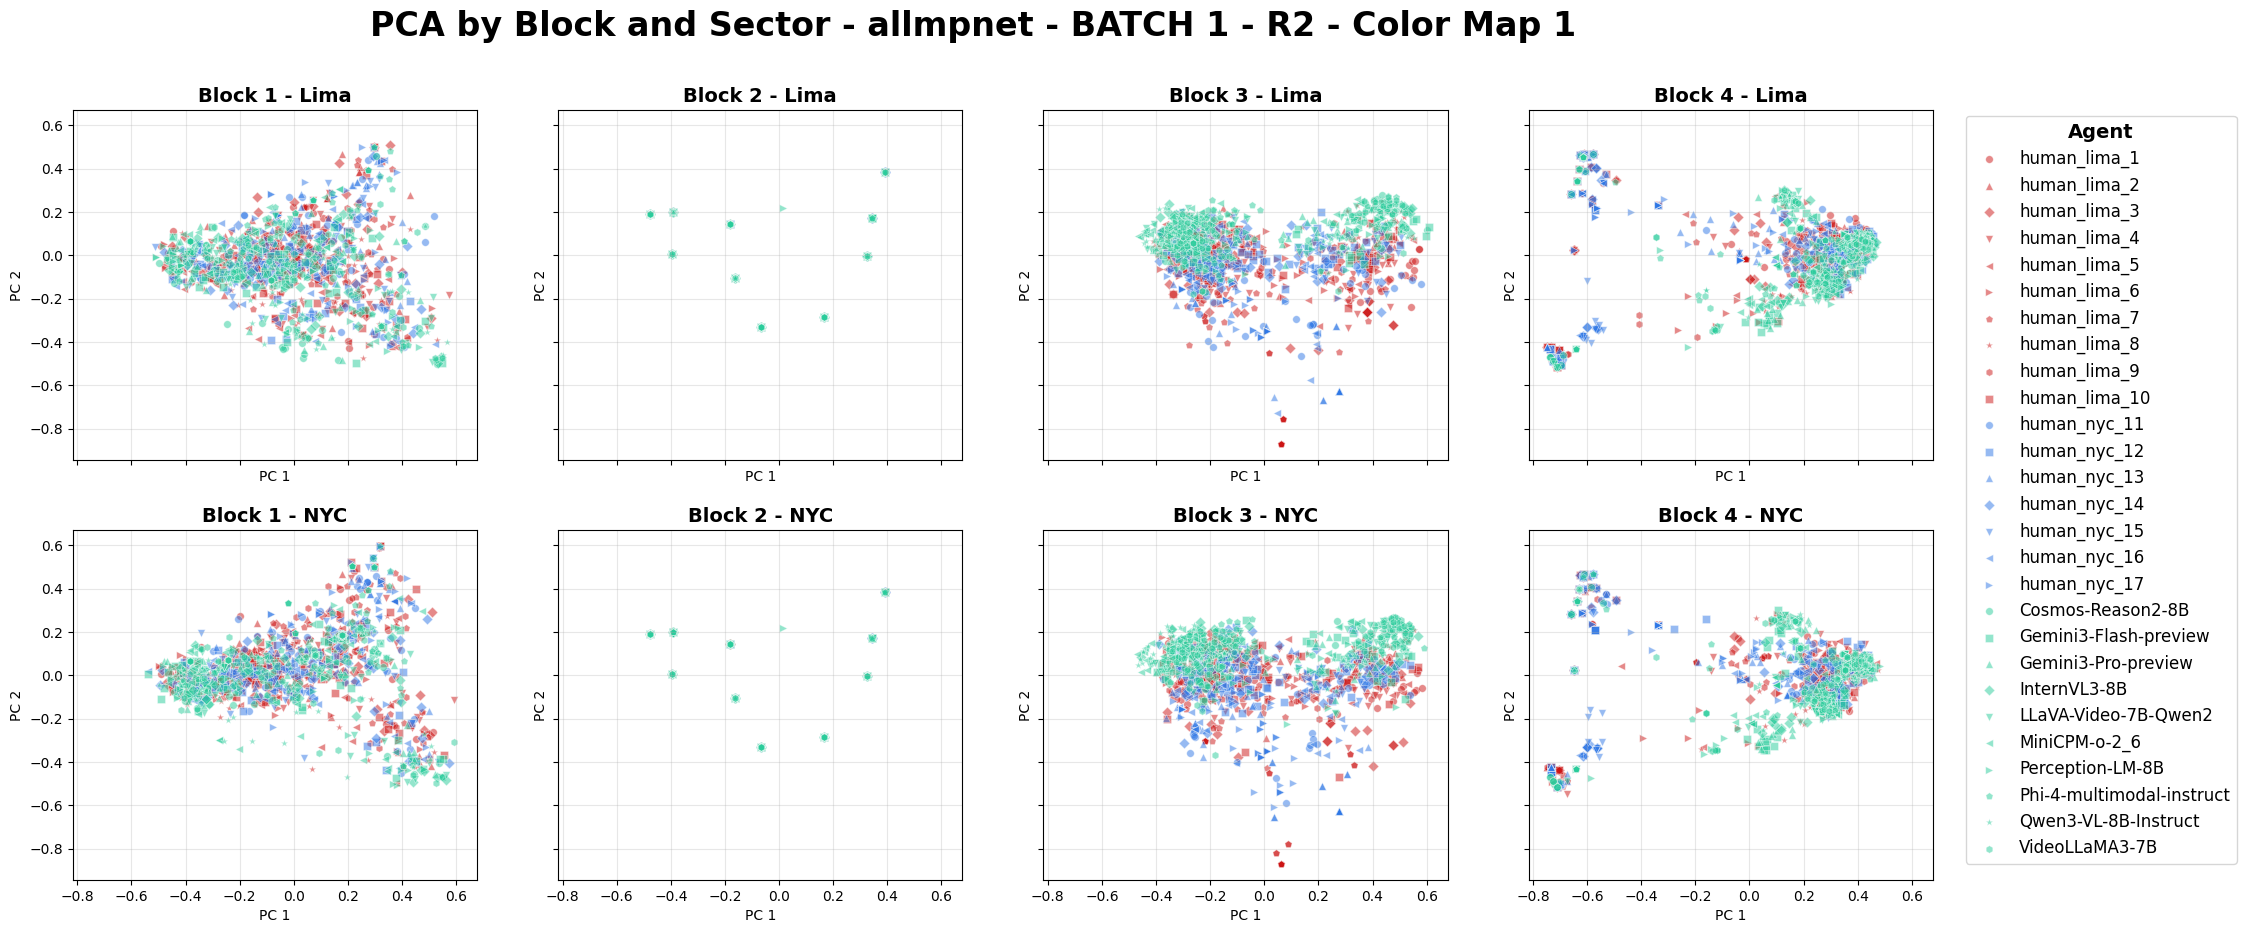

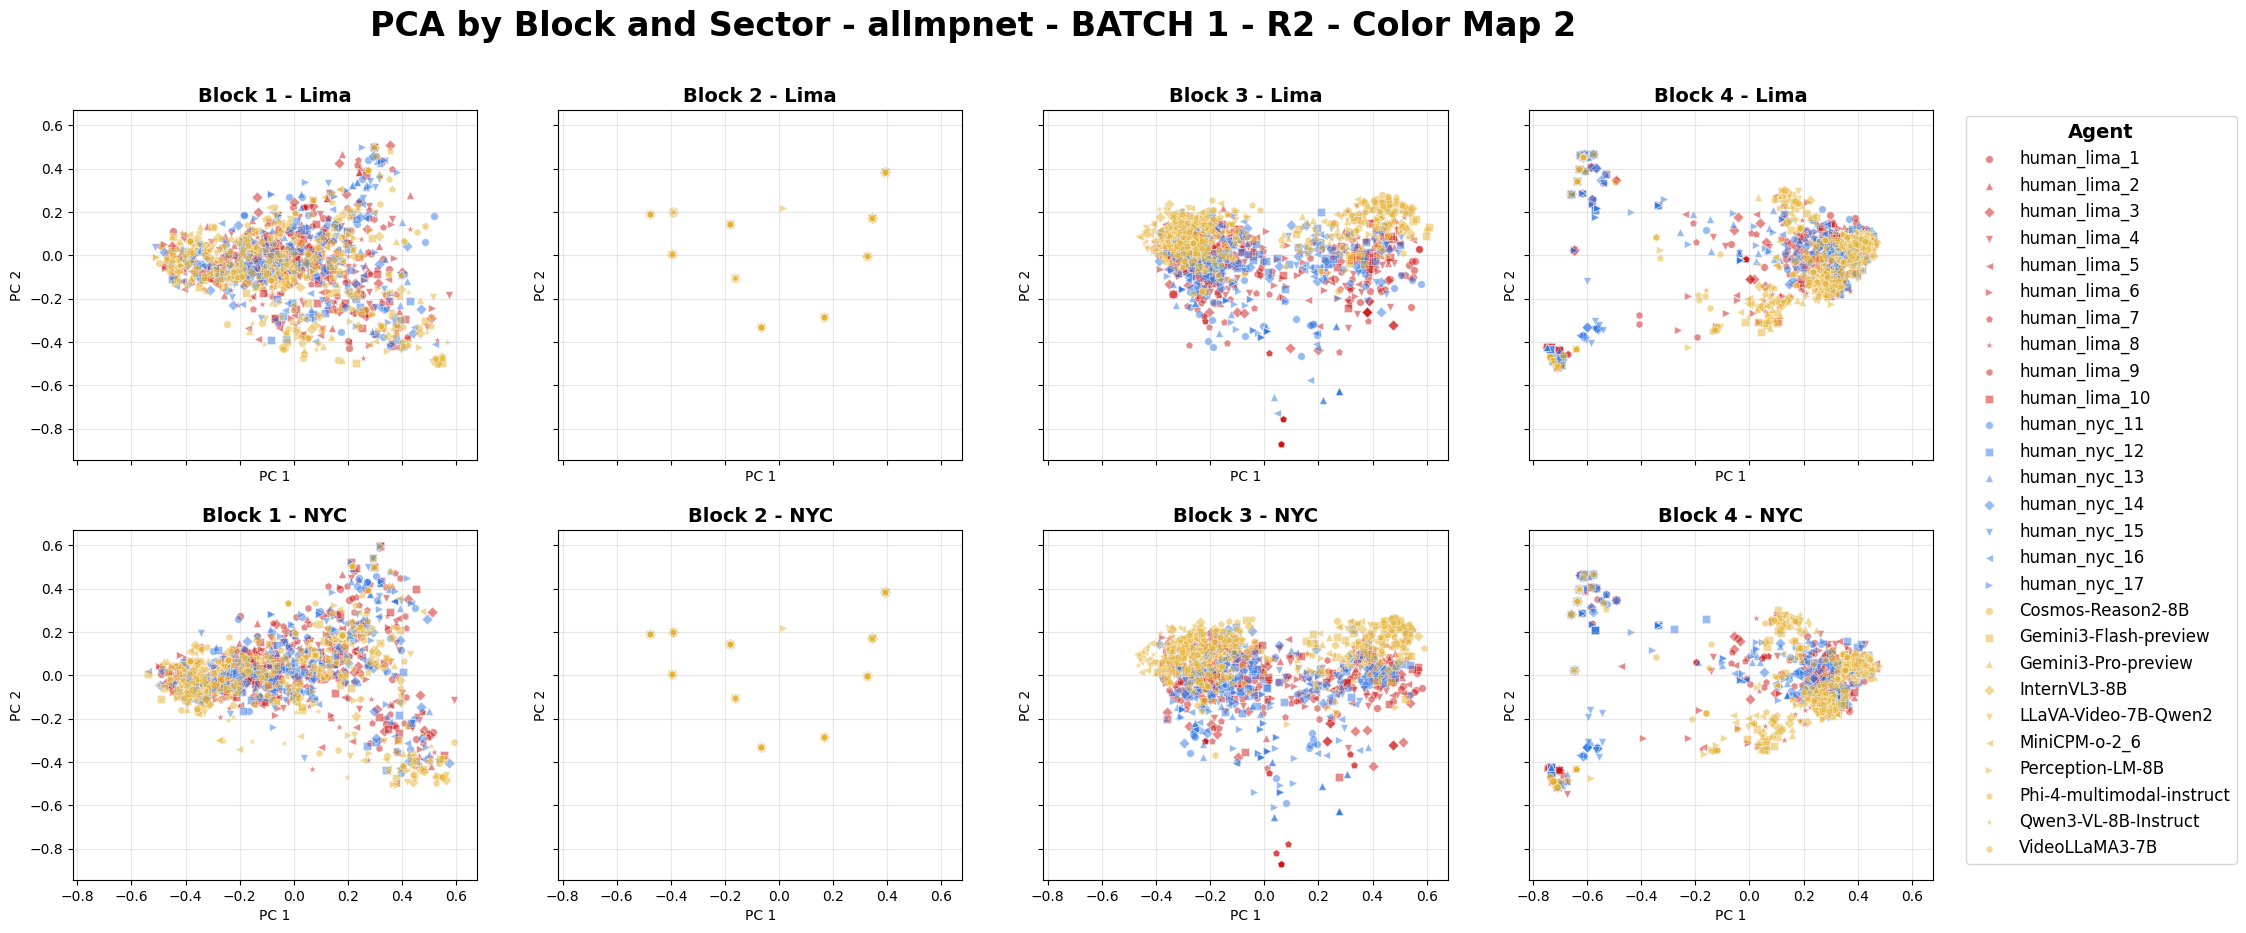

In [17]:
from src.old.config import PLOT_COLORS
color_mapA = {
    "nyc":  PLOT_COLORS["HUMAN_NYC"],
    "lima": PLOT_COLORS["HUMAN_LIMA"],
    "vlm":  "#29CC9B"
}

color_mapB = {
    "nyc":  PLOT_COLORS["HUMAN_NYC"],
    "lima": PLOT_COLORS["HUMAN_LIMA"],
    "vlm":  "#E6B22E"
}

color_mapC = {
    "nyc":  PLOT_COLORS["HUMAN_NYC"],
    "lima": PLOT_COLORS["HUMAN_LIMA"],
    "vlm":  "#9E3DCC"
}

color_mapD = {
    "nyc":  PLOT_COLORS["HUMAN_NYC"],
    "lima": PLOT_COLORS["HUMAN_LIMA"],
    "vlm":  "#00FF4C"
}

possible_color_maps = [color_mapA, color_mapB, color_mapC, color_mapD]
embed_cache = load_embeddings_cache(path)
embeddings_arr = build_embeding_matrix_first(df_answers_first,embed_cache)
print(f"Embeddings array shape: {embeddings_arr.shape}")

for i, color_map in enumerate(possible_color_maps):
    print(f"Plotting with color map {i+1}...")
    f = plot_embeds(df_answers_first, embeddings_arr,color_map,f"PCA by Block and Sector - allmpnet - BATCH 1 - R2 - Color Map {i+1}")
    f.savefig(f"./pca_by_block_sector_color_map_{i+1}.png", dpi=300, bbox_inches='tight')

Plotting with color map 1...
Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries

=== PCA por Block y Sector (Grid) ===
Plotting with color map 2...
Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries

=== PCA por Block y Sector (Grid) ===
Plotting with color map 3...
Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries

=== PCA por Block y Sector (Grid) ===
Plotting with color map 4...
Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 

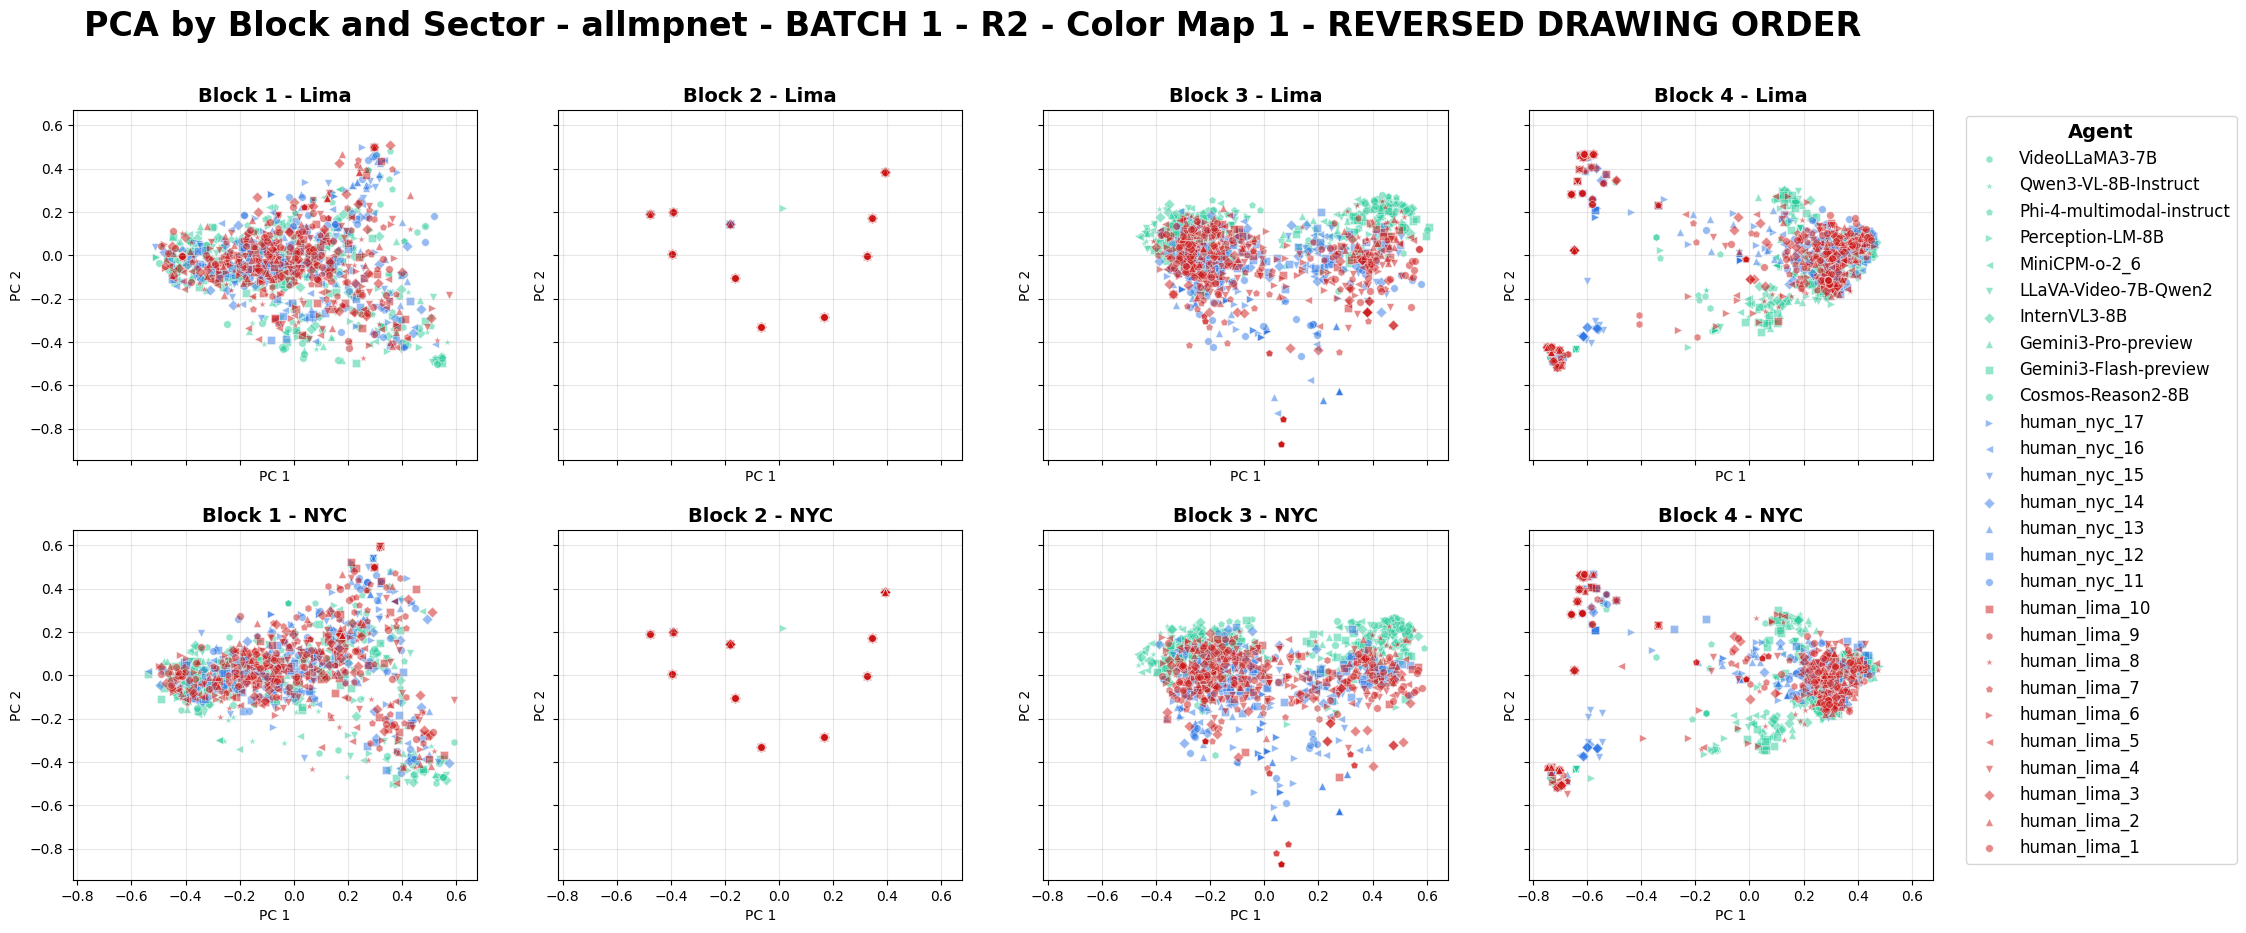

Error in callback <function flush_figures at 0x00000114458E18A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [32]:
for i, color_map in enumerate(possible_color_maps):
    print(f"Plotting with color map {i+1}...")
    f = plot_embeds(df_answers_first, embeddings_arr,color_map,f"PCA by Block and Sector - allmpnet - BATCH 1 - R2 - Color Map {i+1} - REVERSED DRAWING ORDER",True)
    f.savefig(f"./pca_by_block_sector_color_map_{i+1}.png", dpi=300, bbox_inches='tight')

Starting dimensionality reduction by blocks...
Processing block 1 with 2700 entries
Processing block 2 with 2700 entries
Processing block 3 with 2700 entries
Processing block 4 with 2700 entries

=== PCA por Block y Sector (Grid) ===


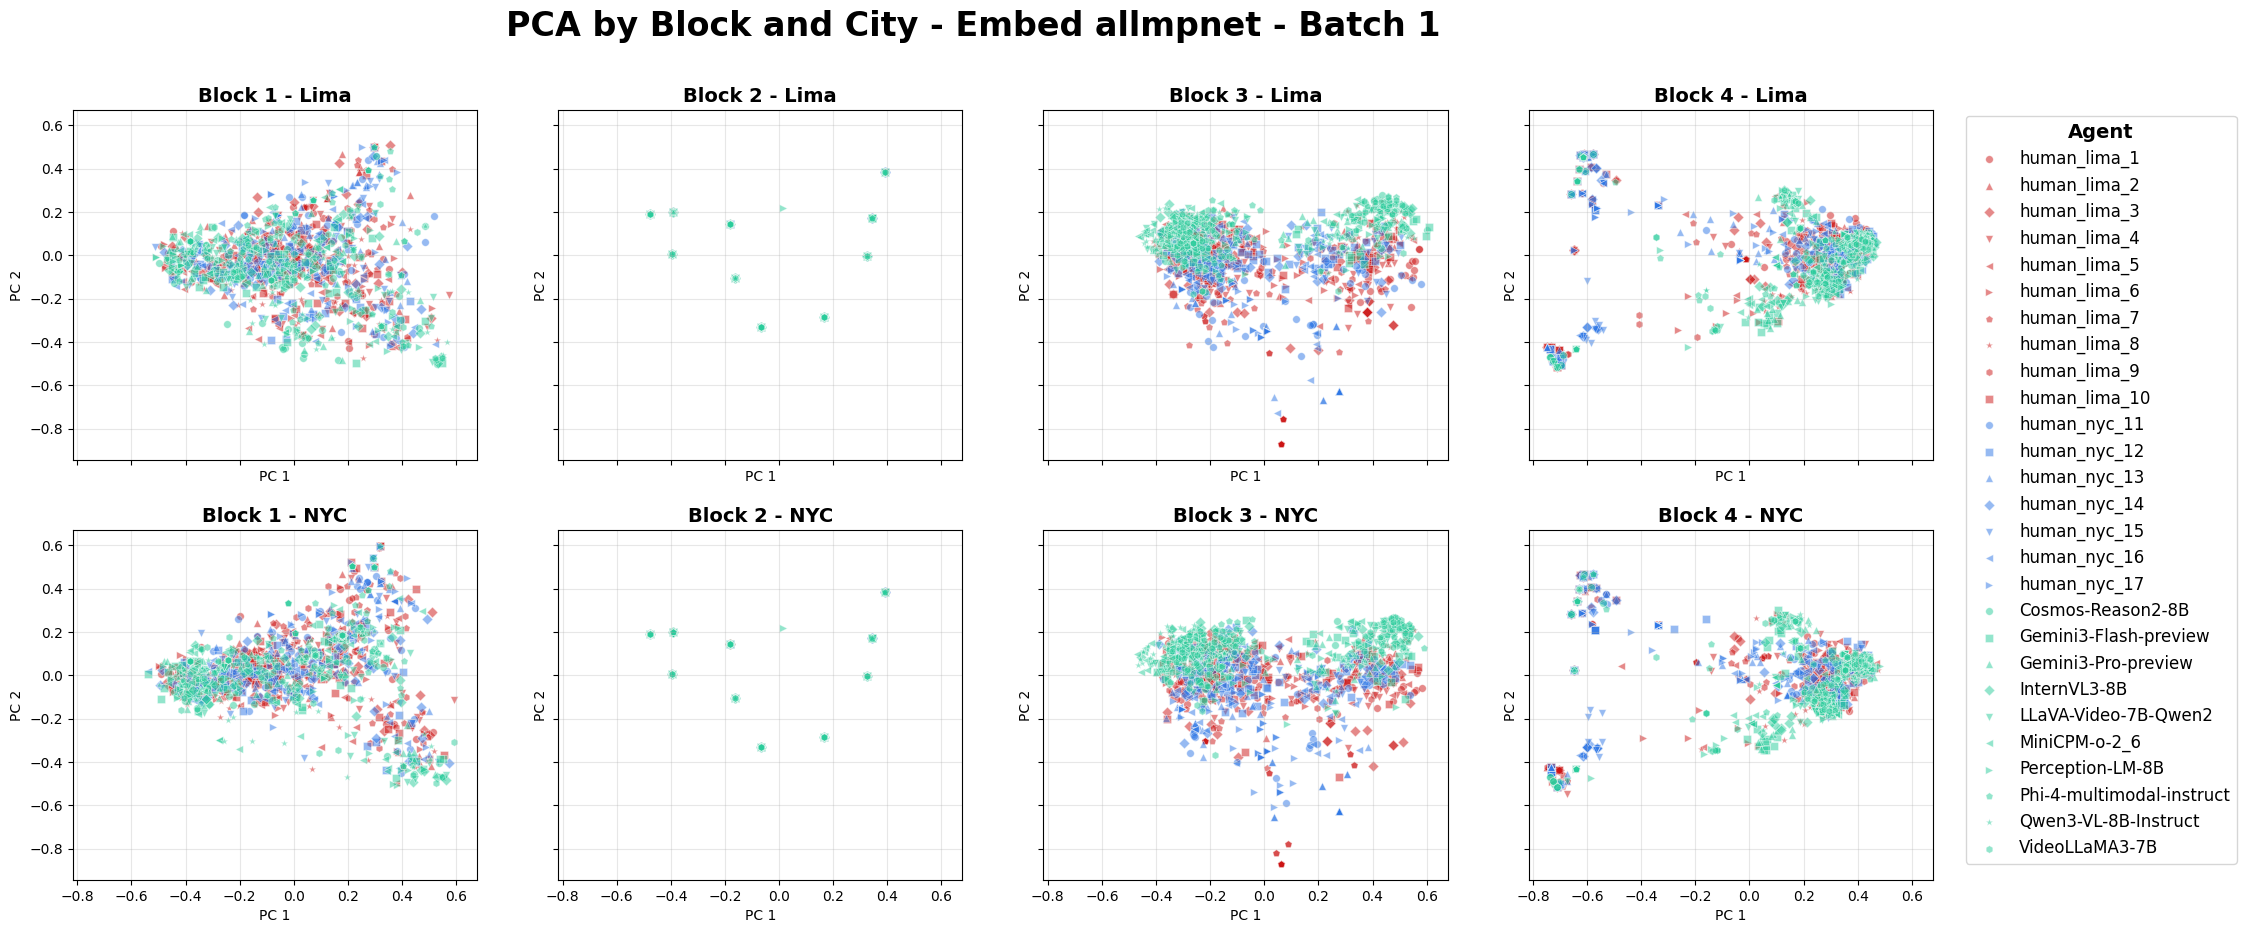

In [18]:
#final
f = plot_embeds(df_answers_first, embeddings_arr,color_mapA,f"PCA by Block and City - Embed allmpnet - Batch 1", reverse_z_order=False)
f.savefig(f"./pca_by_block_sector_final.png", dpi=300, bbox_inches='tight')